# Load Data

In [1]:
import sys
print(sys.version)


3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]


In [2]:
!pip install numpy


  Using cached numpy-2.2.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.5-cp311-cp311-win_amd64.whl (12.9 MB)


In [1]:
import numpy as np

loaded = np.load("ecg_dataset.npz")
X = loaded["x"]
y = loaded["y"]

In [2]:
X_2d = X.transpose(0, 2, 1)  # shape is (n_samples, 12, 5000)

# Step 2: Add a channel dimension (like grayscale image)
X_2d = X_2d[..., np.newaxis]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42, stratify=y)

# Model Creation

In [37]:
!pip uninstall -y tensorflow
!pip cache purge

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Files removed: 204 (445.8 MB)


In [38]:
!pip install tensorflow


   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/375.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/375.9 MB ? eta -:--:--
   ---

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\CHANUKA ATHALAGE\\AppData\\Local\\Temp\\pip-unpack-c1m0yh03\\tensorflow-2.19.0-cp311-cp311-win_amd64.whl'
Check the permissions.



In [4]:
import tensorflow as tf
print(tf.__version__)


2.17.1


In [4]:
# Define how many dense units you want globally
dense_units = 64  # ✅ Change to 32, 128, 256, etc. as needed

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

def build_2d_cnn(
    input_shape=(12, 5000, 1),
    dropout_rate=0.3,
    l2_strength=0.001
):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(dropout_rate)(x)

    outputs = Dense(1, activation='sigmoid')(x)  # binary classification

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [5]:
# Step 2: Compile and prepare callbacks (using global dense_units)
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

# Build the model (dense_units is already defined globally)
model = build_2d_cnn(
    input_shape=(12, 5000, 1),
    dropout_rate=0.3,
    l2_strength=0.001
)

# Compile with binary classification metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Set callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

# Compute class weights to balance the dataset
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))


In [6]:
print(f"✅ Model dense units: {model.get_layer(index=-3).units}")  # Should print: 64, 128, etc.


✅ Model dense units: 64


In [7]:
# Step 3: Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    verbose=1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights  # Remove or comment out if your dataset is balanced
)


Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 951s 3s/step - accuracy: 0.7075 - loss: 1.4211 - precision: 0.6211 - recall: 0.7040 - val_accuracy: 0.7767 - val_loss: 0.8097 - val_precision: 0.9189 - val_recall: 0.4887 - learning_rate: 0.0010
Epoch 2/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 880s 3s/step - accuracy: 0.8336 - loss: 0.7117 - precision: 0.8147 - recall: 0.7558 - val_accuracy: 0.8577 - val_loss: 0.6708 - val_precision: 0.8431 - val_recall: 0.7947 - learning_rate: 0.0010
Epoch 3/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 873s 3s/step - accuracy: 0.8438 - loss: 0.6922 - precision: 0.8166 - recall: 0.7877 - val_accuracy: 0.8462 - val_loss: 0.7839 - val_precision: 0.8308 - val_recall: 0.7762 - learning_rate: 0.0010
Epoch 4/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 901s 3s/step - accuracy: 0.8577 - loss: 0.7223 - precision: 0.8287 - recall: 0.8055 - val_accuracy: 0.8189 - val_loss: 0.7792 - val_precision: 0.7445 - val_recall: 0.8378 - learning_rate: 0.0010
Epoch 5/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 867s 3s/step - 

In [8]:
# Step 4: Evaluate the trained model on the test set
loss, acc, precision, recall = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {acc:.4f}")
print(f"✅ Test Loss: {loss:.4f}")
print(f"✅ Test Precision: {precision:.4f}")
print(f"✅ Test Recall: {recall:.4f}")


✅ Test Accuracy: 0.8719
✅ Test Loss: 0.5728
✅ Test Precision: 0.8665
✅ Test Recall: 0.8025


In [9]:
from datetime import datetime

print("✅ Confirming unique evaluation result...")
print(f"🕒 Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✅ Accuracy : {acc:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall   : {recall:.4f}")
print(f"✅ Loss     : {loss:.4f}")


✅ Confirming unique evaluation result...
🕒 Timestamp: 2025-05-11 23:30:21
✅ Accuracy : 0.8719
✅ Precision: 0.8665
✅ Recall   : 0.8025
✅ Loss     : 0.5728


In [21]:
!pip install seaborn

   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.6 MB 9.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.6 MB 10.7 MB/s eta 0:00:01
   -------------------- ------------------- 6.0/11.6 MB 10.0 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.6 MB 9.4 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.6 MB 9.4 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.6 MB 7.9 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.6 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 7.4 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------

95/95 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step


✅ Model saved: models/3-layers/ecg_model_acc0.8719_loss0.5728_nodes64_dropout0.5_l2_0.001_20250511_233105.h5


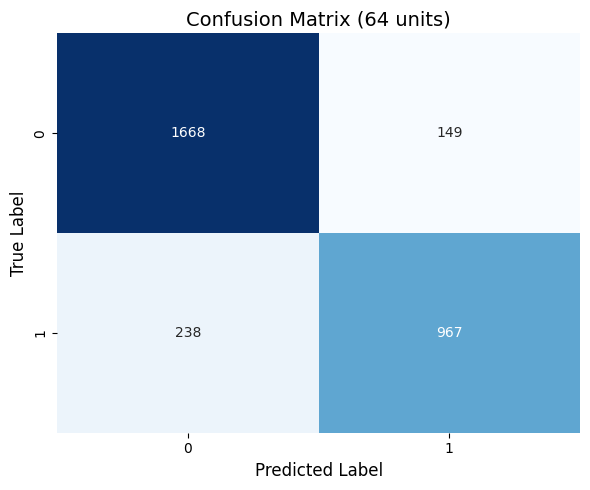

✅ Confusion matrix saved: models/3-layers/ecg_model_acc0.8719_loss0.5728_nodes64_dropout0.5_l2_0.001_20250511_233105_cm.png
📝 Classification Report:
               precision    recall  f1-score   support

           0     0.8751    0.9180    0.8961      1817
           1     0.8665    0.8025    0.8333      1205

    accuracy                         0.8719      3022
   macro avg     0.8708    0.8602    0.8647      3022
weighted avg     0.8717    0.8719    0.8710      3022



In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime

# --- Evaluate the model (already done earlier, this is optional repeat) ---
# loss, acc, precision, recall = model.evaluate(X_test, y_test, verbose=0)

# --- Generate predictions for confusion matrix ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix ({dense_units} units)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()

# --- File naming using live parameters ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
dropout_rate = 0.5
l2_strength = 0.001

base_name = (
    f"ecg_model_acc{acc:.4f}_loss{loss:.4f}"
    f"_nodes{dense_units}_dropout{dropout_rate}_l2_{l2_strength}_{timestamp}"
)

# --- Save model ---
os.makedirs("models/3-layers", exist_ok=True)
model.save(f"models/3-layers/{base_name}.h5")
print(f"✅ Model saved: models/3-layers/{base_name}.h5")

# --- Save confusion matrix image ---
plt.savefig(f"models/3-layers/{base_name}_cm.png", dpi=300)
plt.show()
print(f"✅ Confusion matrix saved: models/3-layers/{base_name}_cm.png")

# --- Classification report ---
report = classification_report(y_test, y_pred, digits=4)
print("📝 Classification Report:\n", report)


In [11]:
import json
from datetime import datetime

# Use global dense_units instead of redefining it
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_name = f"ecg_model_acc{acc:.4f}_loss{loss:.4f}_nodes{dense_units}_dropout{dropout_rate}_l2_{l2_strength}_{timestamp}"

# Metadata dictionary
meta = {
    "filename": f"{base_name}.h5",
    "timestamp": timestamp,
    "accuracy": float(acc),
    "loss": float(loss),
    "precision": float(precision),
    "recall": float(recall),
    "dense_nodes": dense_units,
    "dropout": dropout_rate,
    "l2_strength": l2_strength
}

# Save to JSON
meta_path = f"models/3-layers/{base_name}_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=4)

print(f"✅ Metadata saved as: {meta_path}")


✅ Metadata saved as: models/3-layers/ecg_model_acc0.8719_loss0.5728_nodes64_dropout0.5_l2_0.001_20250511_233146_meta.json


In [13]:
import json
import os
from tabulate import tabulate  

folder = "models/3-layers"

rows = []
for filename in os.listdir(folder):
    if filename.endswith(".json"):
        with open(os.path.join(folder, filename), 'r') as f:
            data = json.load(f)
            rows.append([
                data.get("filename", filename),
                round(data.get("accuracy", 0), 4),
                round(data.get("precision", 0), 4),
                round(data.get("recall", 0), 4),
                round(data.get("loss", 0), 4)
            ])

headers = ["Model", "Accuracy", "Precision", "Recall", "Loss"]

print(tabulate(rows, headers=headers, tablefmt="github"))


| Model                                                                          |   Accuracy |   Precision |   Recall |   Loss |
|--------------------------------------------------------------------------------|------------|-------------|----------|--------|
| ecg_model_acc0.8355_loss0.4985_nodes128_dropout0.5_l2_0.001_20250511_184216.h5 |     0.8355 |      0.859  |   0.7029 | 0.4985 |
| ecg_model_acc0.8719_loss0.5728_nodes64_dropout0.5_l2_0.001_20250511_233146.h5  |     0.8719 |      0.8665 |   0.8025 | 0.5728 |
